# Inferential statistical testing

This notebook performs the inferential-analysis stage for the immutable formal AQuA experiment:

- **Experiment:** `experiment-2026-08-03T14-15-25-809Z-f77080fe`
- **Design:** 3 workflows × 3 specifications × 10 independent runs
- **Workflow order:** one-shot → quality-focused → automated-refinement
- **Specification order:** todo → quiz → booking

The analysis:

- retains all 90 runs, including legitimate zero-refinement automated runs;
- keeps missing values distinct from legitimate zero values;
- treats repetition labels as independent runs rather than repeated measures;
- uses sequence only for temporal-drift sensitivity analysis;
- does not construct a composite quality score;
- avoids ordinary logistic regression where sparse cells or complete separation make it unreliable.


In [1]:
# Imports and fixed analysis configuration.
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import confint_proportions_2indep, proportion_confint

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

EXPERIMENT_ID = "experiment-2026-08-03T14-15-25-809Z-f77080fe"
WORKFLOW_ORDER = ["one-shot", "quality-focused", "automated-refinement"]
SPECIFICATION_ORDER = ["todo", "quiz", "booking"]
WORKFLOW_LABELS = {
    "one-shot": "One-shot",
    "quality-focused": "Quality-focused",
    "automated-refinement": "Automated refinement",
}
SPECIFICATION_LABELS = {
    "todo": "To-do List",
    "quiz": "Quiz",
    "booking": "Booking Form",
}
ALPHA = 0.05

# The notebook is expected to be run from its notebooks directory.
analysis_dir = Path.cwd().parent
outputs_dir = analysis_dir / "outputs"
tables_dir = analysis_dir / "tables"
figures_dir = analysis_dir / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

runs_path = outputs_dir / "processed_runs.csv"
iterations_path = outputs_dir / "processed_iterations.csv"

print(f"Analysis directory: {analysis_dir}")
print(f"Run-level data: {runs_path}")
print(f"Iteration-level data: {iterations_path}")


Analysis directory: C:\Users\Administrator\Documents\Development\ai-software-quality-pipeline\analysis\experiment-2026-08-03T14-15-25-809Z-f77080fe
Run-level data: C:\Users\Administrator\Documents\Development\ai-software-quality-pipeline\analysis\experiment-2026-08-03T14-15-25-809Z-f77080fe\outputs\processed_runs.csv
Iteration-level data: C:\Users\Administrator\Documents\Development\ai-software-quality-pipeline\analysis\experiment-2026-08-03T14-15-25-809Z-f77080fe\outputs\processed_iterations.csv


## 1. Load and validate processed datasets

In [2]:
# Load the processed datasets without modifying formal experiment data.
if not runs_path.is_file():
    raise FileNotFoundError(f"Processed run-level dataset not found: {runs_path}")
if not iterations_path.is_file():
    raise FileNotFoundError(f"Processed iteration-level dataset not found: {iterations_path}")

runs = pd.read_csv(
    runs_path,
    parse_dates=["startedAt", "completedAt"],
)
iterations = pd.read_csv(iterations_path)

# Restore nullable booleans explicitly because CSV round-tripping may produce strings.
boolean_columns = [
    column for column in runs.columns
    if column.startswith("initial") or column.startswith("final")
]
boolean_columns = [
    column for column in boolean_columns
    if column.endswith("Passed") or column == "finalAllPassed"
]
boolean_columns += [
    column for column in ["converged", "automatedRefinementUsed"]
    if column in runs.columns
]

def to_nullable_boolean(series: pd.Series) -> pd.Series:
    mapping = {
        True: True, False: False,
        "True": True, "False": False,
        "true": True, "false": False,
        "1": True, "0": False,
        1: True, 0: False,
    }
    return series.map(mapping).astype("boolean")

for column in dict.fromkeys(boolean_columns):
    runs[column] = to_nullable_boolean(runs[column])

# Apply fixed category ordering.
runs["workflow"] = pd.Categorical(
    runs["workflow"], categories=WORKFLOW_ORDER, ordered=True
)
runs["specificationId"] = pd.Categorical(
    runs["specificationId"], categories=SPECIFICATION_ORDER, ordered=True
)
iterations["workflow"] = pd.Categorical(
    iterations["workflow"], categories=WORKFLOW_ORDER, ordered=True
)
iterations["specificationId"] = pd.Categorical(
    iterations["specificationId"], categories=SPECIFICATION_ORDER, ordered=True
)

print(f"Run-level rows: {len(runs)}")
print(f"Iteration-level rows: {len(iterations)}")
print(f"Run-level columns: {len(runs.columns)}")
print(f"Iteration-level columns: {len(iterations.columns)}")


Run-level rows: 90
Iteration-level rows: 125
Run-level columns: 86
Iteration-level columns: 13


In [3]:
# Validate the design, required schema and preservation rules.
required_run_columns = {
    "experimentId", "experimentRunId", "runId", "sequence",
    "specificationId", "workflow", "repetition",
    "finalAllPassed", "finalStaticPassed", "finalRuntimePassed",
    "finalAccessibilityPassed", "finalFunctionalPassed",
    "aiGenerationDurationMs", "workflowDurationMs", "pipelineOverheadMs",
    "totalPromptTokens", "totalOutputTokens", "totalTokens",
    "finalStaticTotalIssues", "finalAccessibilityViolations",
    "finalAccessibilityViolatingNodes", "finalFunctionalFailedTests",
    "refinementIterations",
}
required_initial_columns = {
    "initialAllPassed", "initialStaticPassed", "initialRuntimePassed",
    "initialAccessibilityPassed", "initialFunctionalPassed",
    "initialStaticTotalIssues", "initialAccessibilityViolations",
    "initialAccessibilityViolatingNodes", "initialFunctionalFailedTests",
}
missing_required = sorted((required_run_columns | required_initial_columns) - set(runs.columns))
if missing_required:
    raise KeyError(f"Missing required processed run-level columns: {missing_required}")

validation_rows = []

def add_validation(check: str, passed: bool, detail: str) -> None:
    validation_rows.append({"check": check, "passed": bool(passed), "detail": detail})

add_validation("Experiment ID matches", runs["experimentId"].eq(EXPERIMENT_ID).all(),
               str(runs["experimentId"].value_counts(dropna=False).to_dict()))
add_validation("Exactly 90 run-level rows", len(runs) == 90, f"Observed {len(runs)}")
add_validation("Exactly 30 rows per workflow",
               runs["workflow"].value_counts().reindex(WORKFLOW_ORDER).eq(30).all(),
               str(runs["workflow"].value_counts().reindex(WORKFLOW_ORDER).to_dict()))
add_validation("Exactly 30 rows per specification",
               runs["specificationId"].value_counts().reindex(SPECIFICATION_ORDER).eq(30).all(),
               str(runs["specificationId"].value_counts().reindex(SPECIFICATION_ORDER).to_dict()))
cell_counts = runs.groupby(["specificationId", "workflow"], observed=True).size()
add_validation("Exactly 10 rows per workflow/specification cell",
               cell_counts.eq(10).all(), str(cell_counts.to_dict()))
add_validation("Unique experimentRunId", runs["experimentRunId"].nunique() == 90,
               f"Unique={runs['experimentRunId'].nunique()}")
add_validation("Unique runId", runs["runId"].nunique() == 90,
               f"Unique={runs['runId'].nunique()}")
add_validation("Sequence covers 1-90 exactly once",
               sorted(runs["sequence"].dropna().astype(int).tolist()) == list(range(1, 91)),
               f"Min={runs['sequence'].min()}, max={runs['sequence'].max()}")
automated = runs.loc[runs["workflow"] == "automated-refinement"].copy()
add_validation("All 30 automated-refinement runs retained", len(automated) == 30,
               f"Observed {len(automated)}")
zero_refinement_count = int((automated["refinementIterations"] == 0).sum())
add_validation("Exactly one zero-refinement automated run preserved",
                zero_refinement_count == 1,
                f"Observed {zero_refinement_count}",)
add_validation("Pipeline overhead is non-negative when observed",
               runs["pipelineOverheadMs"].dropna().ge(0).all(),
               f"Negative values={int(runs['pipelineOverheadMs'].dropna().lt(0).sum())}")

validation = pd.DataFrame(validation_rows)
display(validation)
if not validation["passed"].all():
    raise AssertionError("Dataset validation failed. Review the table above.")


,check,passed,detail
0,Experiment ID matches,True,{'experiment-2026-08-03T14-15-25-809Z-f77080fe...
1,Exactly 90 run-level rows,True,Observed 90
2,Exactly 30 rows per workflow,True,"{'one-shot': 30, 'quality-focused': 30, 'autom..."
3,Exactly 30 rows per specification,True,"{'todo': 30, 'quiz': 30, 'booking': 30}"
4,Exactly 10 rows per workflow/specification cell,True,"{('todo', 'one-shot'): 10, ('todo', 'quality-f..."
5,Unique experimentRunId,True,Unique=90
6,Unique runId,True,Unique=90
7,Sequence covers 1-90 exactly once,True,"Min=1, max=90"
8,All 30 automated-refinement runs retained,True,Observed 30
9,Exactly one zero-refinement automated run pres...,True,Observed 1


## 2. Statistical helper functions

Binary comparisons use Fisher's exact test. Effect estimates include risk differences and odds ratios. When a 2×2 table contains a zero cell, the raw odds ratio may be zero or infinite; a Haldane–Anscombe corrected odds ratio and confidence interval are also reported and explicitly labelled.

Continuous and count outcomes use Kruskal–Wallis omnibus tests. Pairwise Mann–Whitney U tests are only interpreted after a significant omnibus test and use Holm correction. Rank-biserial correlation is reported as the pairwise effect size.

Automated-refinement initial-versus-final analyses use exact McNemar tests for binary outcomes and Wilcoxon signed-rank tests for counts.


In [4]:
# General utilities.
def holm_adjust(p_values: pd.Series | list[float]) -> np.ndarray:
    values = np.asarray(p_values, dtype=float)
    adjusted = np.full(values.shape, np.nan, dtype=float)
    valid = np.isfinite(values)
    if valid.any():
        adjusted[valid] = multipletests(values[valid], method="holm")[1]
    return adjusted

def significance_label(p_value: float | None, alpha: float = ALPHA) -> str:
    if p_value is None or not np.isfinite(p_value):
        return "not tested"
    return "statistically significant" if p_value < alpha else "not statistically significant"

def magnitude_rank_biserial(value: float | None) -> str:
    if value is None or not np.isfinite(value):
        return "not estimable"
    absolute = abs(value)
    if absolute < 0.10:
        return "negligible"
    if absolute < 0.30:
        return "small"
    if absolute < 0.50:
        return "moderate"
    return "large"

def wilson_interval(successes: int, n: int, alpha: float = ALPHA) -> tuple[float, float]:
    if n == 0:
        return (np.nan, np.nan)
    low, high = proportion_confint(successes, n, alpha=alpha, method="wilson")
    return float(low), float(high)

def binary_summary(data: pd.DataFrame, outcome: str, grouping: list[str]) -> pd.DataFrame:
    rows = []
    for keys, group in data.groupby(grouping, observed=True, sort=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        observed = group[outcome].dropna().astype(bool)
        n = len(observed)
        passed = int(observed.sum())
        failed = int(n - passed)
        low, high = wilson_interval(passed, n)
        row = dict(zip(grouping, keys))
        row.update({
            "outcome": outcome,
            "n": n,
            "passed": passed,
            "failed": failed,
            "passRate": passed / n if n else np.nan,
            "ci95Low": low,
            "ci95High": high,
        })
        rows.append(row)
    return pd.DataFrame(rows)

def fisher_pairwise(
    data: pd.DataFrame,
    outcome: str,
    group_column: str = "workflow",
    group_order: list[str] | None = None,
    stratum: str = "overall",
) -> pd.DataFrame:
    order = group_order or list(data[group_column].dropna().unique())
    rows = []
    for group_a, group_b in combinations(order, 2):
        a = data.loc[data[group_column] == group_a, outcome].dropna().astype(bool)
        b = data.loc[data[group_column] == group_b, outcome].dropna().astype(bool)
        table = np.array([
            [int(a.sum()), int((~a).sum())],
            [int(b.sum()), int((~b).sum())],
        ], dtype=float)
        raw_or, p_value = stats.fisher_exact(table, alternative="two-sided")

        # Newcombe confidence interval for independent risk difference.
        try:
            rd_low, rd_high = confint_proportions_2indep(
                count1=int(a.sum()), nobs1=len(a),
                count2=int(b.sum()), nobs2=len(b),
                method="newcomb", compare="diff", alpha=ALPHA,
            )
        except Exception:
            rd_low, rd_high = (np.nan, np.nan)

        risk_a = float(a.mean()) if len(a) else np.nan
        risk_b = float(b.mean()) if len(b) else np.nan
        risk_difference = risk_a - risk_b

        zero_cell = bool((table == 0).any())
        corrected_table = table + 0.5 if zero_cell else table.copy()
        corrected_or = (
            corrected_table[0, 0] * corrected_table[1, 1]
            / (corrected_table[0, 1] * corrected_table[1, 0])
        )
        try:
            table_model = Table2x2(corrected_table, shift_zeros=False)
            corrected_ci_low, corrected_ci_high = table_model.oddsratio_confint(alpha=ALPHA)
        except Exception:
            corrected_ci_low, corrected_ci_high = (np.nan, np.nan)

        rows.append({
            "outcome": outcome,
            "stratum": stratum,
            "groupA": group_a,
            "groupB": group_b,
            "nA": len(a),
            "passedA": int(a.sum()),
            "passRateA": risk_a,
            "nB": len(b),
            "passedB": int(b.sum()),
            "passRateB": risk_b,
            "riskDifferenceAminusB": risk_difference,
            "riskDifferenceCi95Low": rd_low,
            "riskDifferenceCi95High": rd_high,
            "oddsRatioRaw": raw_or,
            "zeroCellPresent": zero_cell,
            "oddsRatioCorrected": corrected_or,
            "oddsRatioCorrectedCi95Low": corrected_ci_low,
            "oddsRatioCorrectedCi95High": corrected_ci_high,
            "fisherP": p_value,
        })
    result = pd.DataFrame(rows)
    if not result.empty:
        result["holmP"] = holm_adjust(result["fisherP"])
        result["significantHolm"] = result["holmP"] < ALPHA
    return result

def kruskal_workflow(data: pd.DataFrame, outcome: str, stratum: str = "overall") -> dict:
    groups = []
    ns = {}
    for workflow in WORKFLOW_ORDER:
        values = pd.to_numeric(
            data.loc[data["workflow"] == workflow, outcome], errors="coerce"
        ).dropna()
        groups.append(values.to_numpy())
        ns[workflow] = len(values)

    if any(len(group) == 0 for group in groups):
        return {
            "outcome": outcome, "stratum": stratum,
            "statistic": np.nan, "pValue": np.nan,
            "epsilonSquared": np.nan, "note": "At least one workflow has no observed values.",
            **{f"n_{key}": value for key, value in ns.items()},
        }

    combined = np.concatenate(groups)
    if np.all(combined == combined[0]):
        return {
            "outcome": outcome, "stratum": stratum,
            "statistic": 0.0, "pValue": 1.0,
            "epsilonSquared": 0.0, "note": "Outcome has no variation.",
            **{f"n_{key}": value for key, value in ns.items()},
        }

    statistic, p_value = stats.kruskal(*groups, nan_policy="omit")
    n_total = sum(len(group) for group in groups)
    k = len(groups)
    epsilon_squared = max(0.0, (statistic - k + 1) / (n_total - k)) if n_total > k else np.nan
    return {
        "outcome": outcome, "stratum": stratum,
        "statistic": statistic, "pValue": p_value,
        "epsilonSquared": epsilon_squared, "note": "",
        **{f"n_{key}": value for key, value in ns.items()},
    }

def mann_whitney_pairwise(data: pd.DataFrame, outcome: str, stratum: str = "overall") -> pd.DataFrame:
    rows = []
    for workflow_a, workflow_b in combinations(WORKFLOW_ORDER, 2):
        a = pd.to_numeric(
            data.loc[data["workflow"] == workflow_a, outcome], errors="coerce"
        ).dropna()
        b = pd.to_numeric(
            data.loc[data["workflow"] == workflow_b, outcome], errors="coerce"
        ).dropna()
        if len(a) == 0 or len(b) == 0:
            continue
        if a.nunique() == 1 and b.nunique() == 1 and a.iloc[0] == b.iloc[0]:
            u_statistic, p_value = len(a) * len(b) / 2, 1.0
        else:
            u_statistic, p_value = stats.mannwhitneyu(
                a, b, alternative="two-sided", method="auto"
            )
        rank_biserial = 2 * u_statistic / (len(a) * len(b)) - 1
        rows.append({
            "outcome": outcome,
            "stratum": stratum,
            "groupA": workflow_a,
            "groupB": workflow_b,
            "nA": len(a),
            "medianA": float(a.median()),
            "nB": len(b),
            "medianB": float(b.median()),
            "uStatistic": float(u_statistic),
            "rankBiserialAminusB": float(rank_biserial),
            "effectMagnitude": magnitude_rank_biserial(rank_biserial),
            "pValue": float(p_value),
        })
    result = pd.DataFrame(rows)
    if not result.empty:
        result["holmP"] = holm_adjust(result["pValue"])
        result["significantHolm"] = result["holmP"] < ALPHA
    return result

def exact_mcnemar(initial: pd.Series, final: pd.Series) -> dict:
    paired = pd.DataFrame({"initial": initial, "final": final}).dropna()
    paired["initial"] = paired["initial"].astype(bool)
    paired["final"] = paired["final"].astype(bool)
    improved = int((~paired["initial"] & paired["final"]).sum())
    worsened = int((paired["initial"] & ~paired["final"]).sum())
    discordant = improved + worsened
    if discordant == 0:
        p_value = 1.0
        note = "No discordant pairs; exact McNemar p-value set to 1."
    else:
        p_value = stats.binomtest(
            min(improved, worsened), n=discordant, p=0.5, alternative="two-sided"
        ).pvalue
        note = ""
    return {
        "nPairs": len(paired),
        "initialFailFinalFail": int((~paired["initial"] & ~paired["final"]).sum()),
        "initialFailFinalPass": improved,
        "initialPassFinalFail": worsened,
        "initialPassFinalPass": int((paired["initial"] & paired["final"]).sum()),
        "discordantPairs": discordant,
        "netImprovementProportion": (improved - worsened) / len(paired) if len(paired) else np.nan,
        "exactMcNemarP": p_value,
        "note": note,
    }

def paired_wilcoxon(initial: pd.Series, final: pd.Series) -> dict:
    paired = pd.DataFrame({
        "initial": pd.to_numeric(initial, errors="coerce"),
        "final": pd.to_numeric(final, errors="coerce"),
    }).dropna()
    differences = paired["final"] - paired["initial"]
    nonzero = differences[differences != 0]
    if len(paired) == 0:
        return {"nPairs": 0, "nNonzero": 0, "statistic": np.nan, "pValue": np.nan,
                "matchedRankBiserial": np.nan, "note": "No complete pairs."}
    if len(nonzero) == 0:
        return {
            "nPairs": len(paired), "nNonzero": 0,
            "initialMedian": float(paired["initial"].median()),
            "finalMedian": float(paired["final"].median()),
            "medianChangeFinalMinusInitial": 0.0,
            "improvedCount": 0, "worsenedCount": 0, "unchangedCount": len(paired),
            "statistic": 0.0, "pValue": 1.0,
            "matchedRankBiserial": 0.0,
            "note": "All paired differences are zero; Wilcoxon p-value set to 1.",
        }

    result = stats.wilcoxon(
        paired["final"], paired["initial"],
        alternative="two-sided", zero_method="wilcox", method="auto"
    )
    ranks = stats.rankdata(np.abs(nonzero))
    positive_rank_sum = float(ranks[nonzero > 0].sum())
    negative_rank_sum = float(ranks[nonzero < 0].sum())
    total_rank_sum = positive_rank_sum + negative_rank_sum
    matched_rank_biserial = (
        (positive_rank_sum - negative_rank_sum) / total_rank_sum
        if total_rank_sum else 0.0
    )
    return {
        "nPairs": len(paired),
        "nNonzero": len(nonzero),
        "initialMedian": float(paired["initial"].median()),
        "finalMedian": float(paired["final"].median()),
        "medianChangeFinalMinusInitial": float(differences.median()),
        "improvedCount": int((differences < 0).sum()),  # Lower issue counts are better.
        "worsenedCount": int((differences > 0).sum()),
        "unchangedCount": int((differences == 0).sum()),
        "statistic": float(result.statistic),
        "pValue": float(result.pvalue),
        # Negative values indicate lower final issue counts.
        "matchedRankBiserial": float(matched_rank_biserial),
        "note": "",
    }


## 3. Binary quality outcomes

In [5]:
# Primary and domain-specific binary endpoints.
binary_outcomes = [
    "finalAllPassed",
    "finalStaticPassed",
    "finalRuntimePassed",
    "finalAccessibilityPassed",
    "finalFunctionalPassed",
]

binary_descriptive = pd.concat(
    [binary_summary(runs, outcome, ["workflow"]) for outcome in binary_outcomes],
    ignore_index=True,
)
binary_descriptive["workflow"] = pd.Categorical(
    binary_descriptive["workflow"], categories=WORKFLOW_ORDER, ordered=True
)
binary_descriptive = binary_descriptive.sort_values(["outcome", "workflow"])

binary_descriptive.to_csv(
    tables_dir / "inferential_binary_pass_rates_overall.csv", index=False
)
display(binary_descriptive)


,workflow,outcome,n,passed,failed,passRate,ci95Low,ci95High
11,one-shot,finalAccessibilityPassed,30,3,27,0.1000,0.0346,0.2562
9,quality-focused,finalAccessibilityPassed,30,30,0,1.0000,0.8865,1.0000
10,automated-refinement,finalAccessibilityPassed,30,30,0,1.0000,0.8865,1.0000
2,one-shot,finalAllPassed,30,2,28,0.0667,0.0185,0.2132
0,quality-focused,finalAllPassed,30,19,11,0.6333,0.4551,0.7813
1,automated-refinement,finalAllPassed,30,30,0,1.0000,0.8865,1.0000
14,one-shot,finalFunctionalPassed,30,29,1,0.9667,0.8333,0.9941
12,quality-focused,finalFunctionalPassed,30,27,3,0.9000,0.7438,0.9654
13,automated-refinement,finalFunctionalPassed,30,30,0,1.0000,0.8865,1.0000
8,one-shot,finalRuntimePassed,30,30,0,1.0000,0.8865,1.0000


In [6]:
# Overall pairwise Fisher tests by workflow.
binary_pairwise_overall = pd.concat(
    [fisher_pairwise(runs, outcome) for outcome in binary_outcomes],
    ignore_index=True,
)
binary_pairwise_overall.to_csv(
    tables_dir / "inferential_binary_pairwise_fisher_overall.csv", index=False
)
display(binary_pairwise_overall)


,outcome,stratum,groupA,groupB,nA,passedA,passRateA,nB,passedB,passRateB,riskDifferenceAminusB,riskDifferenceCi95Low,riskDifferenceCi95High,oddsRatioRaw,zeroCellPresent,oddsRatioCorrected,oddsRatioCorrectedCi95Low,oddsRatioCorrectedCi95High,fisherP,holmP,significantHolm
0,finalAllPassed,overall,quality-focused,automated-refinement,30,19,0.6333,30,30,1.0000,-0.3667,-0.5449,-0.1802,0.0000,True,0.0278,0.0015,0.4991,0.0003,0.0003,True
1,finalAllPassed,overall,quality-focused,one-shot,30,19,0.6333,30,2,0.0667,0.5667,0.3359,0.7222,24.1818,False,24.1818,4.8079,121.6251,0.0000,0.0000,True
2,finalAllPassed,overall,automated-refinement,one-shot,30,30,1.0000,30,2,0.0667,0.9333,0.7479,0.9815,inf,True,695.4000,31.9921,"15,115.6641",0.0000,0.0000,True
3,finalStaticPassed,overall,quality-focused,automated-refinement,30,20,0.6667,30,30,1.0000,-0.3333,-0.5122,-0.1523,0.0000,True,0.0320,0.0018,0.5769,0.0008,0.0016,True
4,finalStaticPassed,overall,quality-focused,one-shot,30,20,0.6667,30,14,0.4667,0.2000,-0.0481,0.4166,2.2857,False,2.2857,0.8044,6.4951,0.1923,0.1923,False
5,finalStaticPassed,overall,automated-refinement,one-shot,30,30,1.0000,30,14,0.4667,0.5333,0.3273,0.6977,inf,True,69.4138,3.8883,"1,239.1795",0.0000,0.0000,True
6,finalRuntimePassed,overall,quality-focused,automated-refinement,30,29,0.9667,30,30,1.0000,-0.0333,-0.1667,0.0834,0.0000,True,0.3224,0.0126,8.2353,1.0000,1.0000,False
7,finalRuntimePassed,overall,quality-focused,one-shot,30,29,0.9667,30,30,1.0000,-0.0333,-0.1667,0.0834,0.0000,True,0.3224,0.0126,8.2353,1.0000,1.0000,False
8,finalRuntimePassed,overall,automated-refinement,one-shot,30,30,1.0000,30,30,1.0000,0.0000,-0.1135,0.1135,NaN,True,1.0000,0.0192,52.0356,1.0000,1.0000,False
9,finalAccessibilityPassed,overall,quality-focused,automated-refinement,30,30,1.0000,30,30,1.0000,0.0000,-0.1135,0.1135,NaN,True,1.0000,0.0192,52.0356,1.0000,1.0000,False


In [7]:
# Specification-stratified Fisher tests.
stratified_binary_results = []
stratified_binary_rates = []

for specification in SPECIFICATION_ORDER:
    subset = runs.loc[runs["specificationId"] == specification]
    for outcome in binary_outcomes:
        rates = binary_summary(subset, outcome, ["workflow"])
        rates.insert(0, "specificationId", specification)
        stratified_binary_rates.append(rates)

        result = fisher_pairwise(
            subset,
            outcome,
            stratum=specification,
        )
        result.insert(1, "specificationId", specification)
        stratified_binary_results.append(result)

binary_descriptive_by_specification = pd.concat(
    stratified_binary_rates, ignore_index=True
)
binary_pairwise_by_specification = pd.concat(
    stratified_binary_results, ignore_index=True
)

# Apply Holm correction within each outcome × specification family.
binary_pairwise_by_specification["holmP"] = (
    binary_pairwise_by_specification
    .groupby(["outcome", "specificationId"], observed=True)["fisherP"]
    .transform(lambda series: holm_adjust(series))
)
binary_pairwise_by_specification["significantHolm"] = (
    binary_pairwise_by_specification["holmP"] < ALPHA
)

binary_descriptive_by_specification.to_csv(
    tables_dir / "inferential_binary_pass_rates_by_specification.csv", index=False
)
binary_pairwise_by_specification.to_csv(
    tables_dir / "inferential_binary_pairwise_fisher_by_specification.csv", index=False
)

display(binary_pairwise_by_specification)


,outcome,specificationId,stratum,groupA,groupB,nA,passedA,passRateA,nB,passedB,passRateB,riskDifferenceAminusB,riskDifferenceCi95Low,riskDifferenceCi95High,oddsRatioRaw,zeroCellPresent,oddsRatioCorrected,oddsRatioCorrectedCi95Low,oddsRatioCorrectedCi95High,fisherP,holmP,significantHolm
0,finalAllPassed,todo,todo,quality-focused,automated-refinement,10,8,0.8000,10,10,1.0000,-0.2000,-0.5098,0.1124,0.0000,True,0.1619,0.0068,3.8475,0.4737,0.4737,False
1,finalAllPassed,todo,todo,quality-focused,one-shot,10,8,0.8000,10,2,0.2000,0.6000,0.1618,0.8027,16.0000,False,16.0000,1.7883,143.1503,0.0230,0.0460,True
2,finalAllPassed,todo,todo,automated-refinement,one-shot,10,10,1.0000,10,2,0.2000,0.8000,0.3840,0.9433,inf,True,71.4000,3.0046,"1,696.7437",0.0007,0.0021,True
3,finalStaticPassed,todo,todo,quality-focused,automated-refinement,10,9,0.9000,10,10,1.0000,-0.1000,-0.4042,0.1894,0.0000,True,0.3016,0.0109,8.3316,1.0000,1.0000,False
4,finalStaticPassed,todo,todo,quality-focused,one-shot,10,9,0.9000,10,10,1.0000,-0.1000,-0.4042,0.1894,0.0000,True,0.3016,0.0109,8.3316,1.0000,1.0000,False
5,finalStaticPassed,todo,todo,automated-refinement,one-shot,10,10,1.0000,10,10,1.0000,0.0000,-0.2775,0.2775,NaN,True,1.0000,0.0181,55.2669,1.0000,1.0000,False
6,finalRuntimePassed,todo,todo,quality-focused,automated-refinement,10,10,1.0000,10,10,1.0000,0.0000,-0.2775,0.2775,NaN,True,1.0000,0.0181,55.2669,1.0000,1.0000,False
7,finalRuntimePassed,todo,todo,quality-focused,one-shot,10,10,1.0000,10,10,1.0000,0.0000,-0.2775,0.2775,NaN,True,1.0000,0.0181,55.2669,1.0000,1.0000,False
8,finalRuntimePassed,todo,todo,automated-refinement,one-shot,10,10,1.0000,10,10,1.0000,0.0000,-0.2775,0.2775,NaN,True,1.0000,0.0181,55.2669,1.0000,1.0000,False
9,finalAccessibilityPassed,todo,todo,quality-focused,automated-refinement,10,10,1.0000,10,10,1.0000,0.0000,-0.2775,0.2775,NaN,True,1.0000,0.0181,55.2669,1.0000,1.0000,False


In [8]:
# Dissertation-ready binary comparison table.
binary_dissertation = binary_pairwise_overall.copy()
binary_dissertation["comparison"] = (
    binary_dissertation["groupA"].map(WORKFLOW_LABELS)
    + " vs "
    + binary_dissertation["groupB"].map(WORKFLOW_LABELS)
)
binary_dissertation["passRates"] = (
    (binary_dissertation["passRateA"] * 100).round(1).astype(str)
    + "% vs "
    + (binary_dissertation["passRateB"] * 100).round(1).astype(str)
    + "%"
)
binary_dissertation["riskDifferencePercentagePoints"] = (
    binary_dissertation["riskDifferenceAminusB"] * 100
)
binary_dissertation["riskDifferenceCi95PercentagePoints"] = (
    binary_dissertation["riskDifferenceCi95Low"].mul(100).round(1).astype(str)
    + " to "
    + binary_dissertation["riskDifferenceCi95High"].mul(100).round(1).astype(str)
)
binary_dissertation["oddsRatioDisplay"] = np.where(
    binary_dissertation["zeroCellPresent"],
    binary_dissertation["oddsRatioCorrected"].round(3).astype(str) + " (0.5 corrected)",
    binary_dissertation["oddsRatioRaw"].round(3).astype(str),
)
binary_dissertation["holmPDisplay"] = binary_dissertation["holmP"].map(
    lambda value: "<0.001" if value < 0.001 else f"{value:.3f}"
)
binary_dissertation = binary_dissertation[[
    "outcome", "comparison", "passRates",
    "riskDifferencePercentagePoints", "riskDifferenceCi95PercentagePoints",
    "oddsRatioDisplay", "holmPDisplay", "significantHolm",
]]

binary_dissertation.to_csv(
    tables_dir / "dissertation_binary_workflow_comparisons.csv", index=False
)
display(binary_dissertation)


,outcome,comparison,passRates,riskDifferencePercentagePoints,riskDifferenceCi95PercentagePoints,oddsRatioDisplay,holmPDisplay,significantHolm
0,finalAllPassed,Quality-focused vs Automated refinement,63.3% vs 100.0%,-36.6667,-54.5 to -18.0,0.028 (0.5 corrected),<0.001,True
1,finalAllPassed,Quality-focused vs One-shot,63.3% vs 6.7%,56.6667,33.6 to 72.2,24.182,<0.001,True
2,finalAllPassed,Automated refinement vs One-shot,100.0% vs 6.7%,93.3333,74.8 to 98.2,695.4 (0.5 corrected),<0.001,True
3,finalStaticPassed,Quality-focused vs Automated refinement,66.7% vs 100.0%,-33.3333,-51.2 to -15.2,0.032 (0.5 corrected),0.002,True
4,finalStaticPassed,Quality-focused vs One-shot,66.7% vs 46.7%,20.0000,-4.8 to 41.7,2.286,0.192,False
5,finalStaticPassed,Automated refinement vs One-shot,100.0% vs 46.7%,53.3333,32.7 to 69.8,69.414 (0.5 corrected),<0.001,True
6,finalRuntimePassed,Quality-focused vs Automated refinement,96.7% vs 100.0%,-3.3333,-16.7 to 8.3,0.322 (0.5 corrected),1.000,False
7,finalRuntimePassed,Quality-focused vs One-shot,96.7% vs 100.0%,-3.3333,-16.7 to 8.3,0.322 (0.5 corrected),1.000,False
8,finalRuntimePassed,Automated refinement vs One-shot,100.0% vs 100.0%,0.0000,-11.4 to 11.4,1.0 (0.5 corrected),1.000,False
9,finalAccessibilityPassed,Quality-focused vs Automated refinement,100.0% vs 100.0%,0.0000,-11.4 to 11.4,1.0 (0.5 corrected),1.000,False


## 4. Continuous and count outcomes

In [9]:
continuous_count_outcomes = [
    "aiGenerationDurationMs",
    "workflowDurationMs",
    "pipelineOverheadMs",
    "totalPromptTokens",
    "totalOutputTokens",
    "totalTokens",
    "finalStaticTotalIssues",
    "finalAccessibilityViolations",
    "finalAccessibilityViolatingNodes",
    "finalFunctionalFailedTests",
]

# Long-form descriptive statistics support interpretation of practical importance.
continuous_descriptive_rows = []
for outcome in continuous_count_outcomes:
    for workflow in WORKFLOW_ORDER:
        values = pd.to_numeric(
            runs.loc[runs["workflow"] == workflow, outcome], errors="coerce"
        ).dropna()
        continuous_descriptive_rows.append({
            "outcome": outcome,
            "workflow": workflow,
            "n": len(values),
            "missing": int(runs.loc[runs["workflow"] == workflow, outcome].isna().sum()),
            "mean": values.mean(),
            "standardDeviation": values.std(ddof=1),
            "median": values.median(),
            "q1": values.quantile(0.25),
            "q3": values.quantile(0.75),
            "minimum": values.min(),
            "maximum": values.max(),
            "zeroCount": int((values == 0).sum()),
        })

continuous_descriptive = pd.DataFrame(continuous_descriptive_rows)
continuous_descriptive.to_csv(
    tables_dir / "inferential_continuous_count_descriptive.csv", index=False
)
display(continuous_descriptive)


,outcome,workflow,n,missing,mean,standardDeviation,median,q1,q3,minimum,maximum,zeroCount
0,aiGenerationDurationMs,one-shot,30,0,"25,235.2333","9,890.9115","23,721.5000","18,501.7500","27,820.2500",15604,55982,0
1,aiGenerationDurationMs,quality-focused,30,0,"24,912.6000","15,308.4571","19,957.0000","18,959.2500","24,589.0000",15660,95302,0
2,aiGenerationDurationMs,automated-refinement,30,0,"47,735.8333","13,096.3684","46,899.5000","36,917.7500","54,265.2500",27947,80485,0
3,workflowDurationMs,one-shot,30,0,"28,832.2333","10,332.9429","27,321.0000","21,360.0000","31,480.7500",18208,60445,0
4,workflowDurationMs,quality-focused,30,0,"27,680.4333","15,461.4108","22,050.0000","20,963.5000","27,668.7500",17882,97829,0
5,workflowDurationMs,automated-refinement,30,0,"55,054.2667","15,150.3670","54,094.5000","43,749.7500","61,384.0000",32344,102675,0
6,pipelineOverheadMs,one-shot,30,0,"3,597.0000","2,233.6876","3,121.5000","2,636.2500","3,628.5000",2116,14937,0
7,pipelineOverheadMs,quality-focused,30,0,"2,767.8333","2,712.5254","2,172.5000","2,065.7500","2,404.7500",1939,16937,0
8,pipelineOverheadMs,automated-refinement,30,0,"7,318.4333","3,241.6320","7,097.0000","5,681.2500","7,912.7500",4397,22190,0
9,totalPromptTokens,one-shot,30,0,757.6667,27.8213,743.0000,734.0000,796.0000,734,796,0


In [10]:
# Overall Kruskal-Wallis tests.
kruskal_overall = pd.DataFrame([
    kruskal_workflow(runs, outcome)
    for outcome in continuous_count_outcomes
])
kruskal_overall["holmP"] = holm_adjust(kruskal_overall["pValue"])
kruskal_overall["significantHolm"] = kruskal_overall["holmP"] < ALPHA
kruskal_overall.to_csv(
    tables_dir / "inferential_kruskal_wallis_overall.csv", index=False
)
display(kruskal_overall)


,outcome,stratum,statistic,pValue,epsilonSquared,note,n_one-shot,n_quality-focused,n_automated-refinement,holmP,significantHolm
0,aiGenerationDurationMs,overall,44.4740,0.0000,0.4882,,30,30,30,0.0000,True
1,workflowDurationMs,overall,46.8240,0.0000,0.5152,,30,30,30,0.0000,True
2,pipelineOverheadMs,overall,64.7340,0.0000,0.7211,,30,30,30,0.0000,True
3,totalPromptTokens,overall,72.9375,0.0000,0.8154,,30,30,30,0.0000,True
4,totalOutputTokens,overall,55.9812,0.0000,0.6205,,30,30,30,0.0000,True
5,totalTokens,overall,56.2282,0.0000,0.6233,,30,30,30,0.0000,True
6,finalStaticTotalIssues,overall,20.3709,0.0000,0.2112,,30,30,30,0.0001,True
7,finalAccessibilityViolations,overall,75.6189,0.0000,0.8462,,30,30,30,0.0000,True
8,finalAccessibilityViolatingNodes,overall,73.2209,0.0000,0.8186,,30,30,30,0.0000,True
9,finalFunctionalFailedTests,overall,3.5855,0.1665,0.0182,,30,30,30,0.1665,False


In [11]:
# Pairwise Mann-Whitney tests only after a significant unadjusted omnibus test.
# Holm correction is applied across the three workflow comparisons for each outcome.
pairwise_continuous_results = []
for outcome in continuous_count_outcomes:
    omnibus_p = kruskal_overall.loc[
        kruskal_overall["outcome"] == outcome, "pValue"
    ].iloc[0]
    if np.isfinite(omnibus_p) and omnibus_p < ALPHA:
        pairwise_continuous_results.append(
            mann_whitney_pairwise(runs, outcome)
        )

pairwise_continuous = (
    pd.concat(pairwise_continuous_results, ignore_index=True)
    if pairwise_continuous_results
    else pd.DataFrame()
)
pairwise_continuous.to_csv(
    tables_dir / "inferential_mann_whitney_overall.csv", index=False
)
display(pairwise_continuous)


,outcome,stratum,groupA,groupB,nA,medianA,nB,medianB,uStatistic,rankBiserialAminusB,effectMagnitude,pValue,holmP,significantHolm
0,aiGenerationDurationMs,overall,one-shot,quality-focused,30,"23,721.5000",30,"19,957.0000",521.0000,0.1578,small,0.2973,0.2973,False
1,aiGenerationDurationMs,overall,one-shot,automated-refinement,30,"23,721.5000",30,"46,899.5000",61.0000,-0.8644,large,0.0000,0.0000,True
2,aiGenerationDurationMs,overall,quality-focused,automated-refinement,30,"19,957.0000",30,"46,899.5000",64.0000,-0.8578,large,0.0000,0.0000,True
3,workflowDurationMs,overall,one-shot,quality-focused,30,"27,321.0000",30,"22,050.0000",549.0000,0.2200,small,0.1453,0.1453,False
4,workflowDurationMs,overall,one-shot,automated-refinement,30,"27,321.0000",30,"54,094.5000",56.0000,-0.8756,large,0.0000,0.0000,True
5,workflowDurationMs,overall,quality-focused,automated-refinement,30,"22,050.0000",30,"54,094.5000",53.0000,-0.8822,large,0.0000,0.0000,True
6,pipelineOverheadMs,overall,one-shot,quality-focused,30,"3,121.5000",30,"2,172.5000",816.0000,0.8133,large,0.0000,0.0000,True
7,pipelineOverheadMs,overall,one-shot,automated-refinement,30,"3,121.5000",30,"7,097.0000",30.5000,-0.9322,large,0.0000,0.0000,True
8,pipelineOverheadMs,overall,quality-focused,automated-refinement,30,"2,172.5000",30,"7,097.0000",30.0000,-0.9333,large,0.0000,0.0000,True
9,totalPromptTokens,overall,one-shot,quality-focused,30,743.0000,30,906.0000,0.0000,-1.0000,large,0.0000,0.0000,True


In [12]:
# Specification-stratified non-parametric comparisons.
kruskal_by_specification_rows = []
pairwise_by_specification_rows = []

for specification in SPECIFICATION_ORDER:
    subset = runs.loc[runs["specificationId"] == specification]
    for outcome in continuous_count_outcomes:
        omnibus = kruskal_workflow(subset, outcome, stratum=specification)
        omnibus["specificationId"] = specification
        kruskal_by_specification_rows.append(omnibus)
        if np.isfinite(omnibus["pValue"]) and omnibus["pValue"] < ALPHA:
            pairwise = mann_whitney_pairwise(
                subset, outcome, stratum=specification
            )
            pairwise["specificationId"] = specification
            pairwise_by_specification_rows.append(pairwise)

kruskal_by_specification = pd.DataFrame(kruskal_by_specification_rows)
kruskal_by_specification["holmPWithinSpecification"] = (
    kruskal_by_specification
    .groupby("specificationId", observed=True)["pValue"]
    .transform(lambda series: holm_adjust(series))
)
kruskal_by_specification["significantHolmWithinSpecification"] = (
    kruskal_by_specification["holmPWithinSpecification"] < ALPHA
)

pairwise_by_specification = (
    pd.concat(pairwise_by_specification_rows, ignore_index=True)
    if pairwise_by_specification_rows
    else pd.DataFrame()
)

kruskal_by_specification.to_csv(
    tables_dir / "inferential_kruskal_wallis_by_specification.csv", index=False
)
pairwise_by_specification.to_csv(
    tables_dir / "inferential_mann_whitney_by_specification.csv", index=False
)

display(kruskal_by_specification)
display(pairwise_by_specification)


,outcome,stratum,statistic,pValue,epsilonSquared,note,n_one-shot,n_quality-focused,n_automated-refinement,specificationId,holmPWithinSpecification,significantHolmWithinSpecification
0,aiGenerationDurationMs,todo,13.3858,0.0012,0.4217,,10,10,10,todo,0.0037,True
1,workflowDurationMs,todo,14.0929,0.0009,0.4479,,10,10,10,todo,0.0035,True
2,pipelineOverheadMs,todo,18.4615,0.0001,0.6097,,10,10,10,todo,0.0005,True
3,totalPromptTokens,todo,23.0730,0.0000,0.7805,,10,10,10,todo,0.0001,True
4,totalOutputTokens,todo,20.3174,0.0000,0.6784,,10,10,10,todo,0.0002,True
5,totalTokens,todo,22.7174,0.0000,0.7673,,10,10,10,todo,0.0001,True
6,finalStaticTotalIssues,todo,2.0000,0.3679,0.0000,,10,10,10,todo,0.7358,False
7,finalAccessibilityViolations,todo,21.0909,0.0000,0.7071,,10,10,10,todo,0.0002,True
8,finalAccessibilityViolatingNodes,todo,20.5234,0.0000,0.6861,,10,10,10,todo,0.0002,True
9,finalFunctionalFailedTests,todo,2.0000,0.3679,0.0000,,10,10,10,todo,0.7358,False


,outcome,stratum,groupA,groupB,nA,medianA,nB,medianB,uStatistic,rankBiserialAminusB,effectMagnitude,pValue,holmP,significantHolm,specificationId
0,aiGenerationDurationMs,todo,one-shot,quality-focused,10,"23,027.5000",10,"19,240.0000",53.0000,0.0600,negligible,0.8501,0.8501,False,todo
1,aiGenerationDurationMs,todo,one-shot,automated-refinement,10,"23,027.5000",10,"37,495.0000",10.0000,-0.8000,large,0.0028,0.0057,True,todo
2,aiGenerationDurationMs,todo,quality-focused,automated-refinement,10,"19,240.0000",10,"37,495.0000",7.0000,-0.8600,large,0.0013,0.0039,True,todo
3,workflowDurationMs,todo,one-shot,quality-focused,10,"26,785.0000",10,"21,580.5000",56.0000,0.1200,small,0.6776,0.6776,False,todo
4,workflowDurationMs,todo,one-shot,automated-refinement,10,"26,785.0000",10,"45,149.5000",8.0000,-0.8400,large,0.0017,0.0039,True,todo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,finalAccessibilityViolations,booking,one-shot,automated-refinement,10,1.0000,10,0.0000,100.0000,1.0000,large,0.0000,0.0000,True,booking
74,finalAccessibilityViolations,booking,quality-focused,automated-refinement,10,0.0000,10,0.0000,50.0000,0.0000,negligible,1.0000,1.0000,False,booking
75,finalAccessibilityViolatingNodes,booking,one-shot,quality-focused,10,4.0000,10,0.0000,100.0000,1.0000,large,0.0000,0.0001,True,booking
76,finalAccessibilityViolatingNodes,booking,one-shot,automated-refinement,10,4.0000,10,0.0000,100.0000,1.0000,large,0.0000,0.0001,True,booking


In [13]:
# Dissertation-ready non-parametric summary.
continuous_dissertation = kruskal_overall[[
    "outcome", "statistic", "pValue", "holmP",
    "epsilonSquared", "significantHolm", "note"
]].copy()
continuous_dissertation["pDisplay"] = continuous_dissertation["holmP"].map(
    lambda value: "" if not np.isfinite(value)
    else ("<0.001" if value < 0.001 else f"{value:.3f}")
)
continuous_dissertation["effectInterpretation"] = continuous_dissertation["epsilonSquared"].map(
    lambda value: (
        "not estimable" if not np.isfinite(value)
        else "negligible" if value < 0.01
        else "small" if value < 0.06
        else "moderate" if value < 0.14
        else "large"
    )
)
continuous_dissertation.to_csv(
    tables_dir / "dissertation_kruskal_wallis_summary.csv", index=False
)
display(continuous_dissertation)


,outcome,statistic,pValue,holmP,epsilonSquared,significantHolm,note,pDisplay,effectInterpretation
0,aiGenerationDurationMs,44.4740,0.0000,0.0000,0.4882,True,,<0.001,large
1,workflowDurationMs,46.8240,0.0000,0.0000,0.5152,True,,<0.001,large
2,pipelineOverheadMs,64.7340,0.0000,0.0000,0.7211,True,,<0.001,large
3,totalPromptTokens,72.9375,0.0000,0.0000,0.8154,True,,<0.001,large
4,totalOutputTokens,55.9812,0.0000,0.0000,0.6205,True,,<0.001,large
5,totalTokens,56.2282,0.0000,0.0000,0.6233,True,,<0.001,large
6,finalStaticTotalIssues,20.3709,0.0000,0.0001,0.2112,True,,<0.001,large
7,finalAccessibilityViolations,75.6189,0.0000,0.0000,0.8462,True,,<0.001,large
8,finalAccessibilityViolatingNodes,73.2209,0.0000,0.0000,0.8186,True,,<0.001,large
9,finalFunctionalFailedTests,3.5855,0.1665,0.1665,0.0182,False,,0.167,small


## 5. Automated-refinement paired analysis

In [14]:
automated = runs.loc[
    runs["workflow"] == "automated-refinement"
].copy()

paired_binary_map = {
    "allPassed": ("initialAllPassed", "finalAllPassed"),
    "staticPassed": ("initialStaticPassed", "finalStaticPassed"),
    "runtimePassed": ("initialRuntimePassed", "finalRuntimePassed"),
    "accessibilityPassed": (
        "initialAccessibilityPassed", "finalAccessibilityPassed"
    ),
    "functionalPassed": ("initialFunctionalPassed", "finalFunctionalPassed"),
}

mcnemar_rows = []
for outcome, (initial_column, final_column) in paired_binary_map.items():
    result = exact_mcnemar(
        automated[initial_column], automated[final_column]
    )
    result.update({
        "outcome": outcome,
        "initialColumn": initial_column,
        "finalColumn": final_column,
    })
    mcnemar_rows.append(result)

mcnemar_results = pd.DataFrame(mcnemar_rows)
mcnemar_results["holmP"] = holm_adjust(mcnemar_results["exactMcNemarP"])
mcnemar_results["significantHolm"] = mcnemar_results["holmP"] < ALPHA
mcnemar_results.to_csv(
    tables_dir / "inferential_automated_exact_mcnemar.csv", index=False
)
display(mcnemar_results)


,nPairs,initialFailFinalFail,initialFailFinalPass,initialPassFinalFail,initialPassFinalPass,discordantPairs,netImprovementProportion,exactMcNemarP,note,outcome,initialColumn,finalColumn,holmP,significantHolm
0,30,0,28,0,2,28,0.9333,0.0000,,allPassed,initialAllPassed,finalAllPassed,0.0000,True
1,30,0,19,0,11,19,0.6333,0.0000,,staticPassed,initialStaticPassed,finalStaticPassed,0.0000,True
2,30,0,0,0,30,0,0.0000,1.0000,No discordant pairs; exact McNemar p-value set...,runtimePassed,initialRuntimePassed,finalRuntimePassed,1.0000,False
3,30,0,25,0,5,25,0.8333,0.0000,,accessibilityPassed,initialAccessibilityPassed,finalAccessibilityPassed,0.0000,True
4,30,0,1,0,29,1,0.0333,1.0000,,functionalPassed,initialFunctionalPassed,finalFunctionalPassed,1.0000,False


In [15]:
paired_count_map = {
    "staticTotalIssues": (
        "initialStaticTotalIssues", "finalStaticTotalIssues"
    ),
    "accessibilityViolations": (
        "initialAccessibilityViolations", "finalAccessibilityViolations"
    ),
    "accessibilityViolatingNodes": (
        "initialAccessibilityViolatingNodes",
        "finalAccessibilityViolatingNodes",
    ),
    "functionalFailedTests": (
        "initialFunctionalFailedTests", "finalFunctionalFailedTests"
    ),
}

wilcoxon_rows = []
for outcome, (initial_column, final_column) in paired_count_map.items():
    result = paired_wilcoxon(
        automated[initial_column], automated[final_column]
    )
    result.update({
        "outcome": outcome,
        "initialColumn": initial_column,
        "finalColumn": final_column,
    })
    wilcoxon_rows.append(result)

wilcoxon_results = pd.DataFrame(wilcoxon_rows)
wilcoxon_results["holmP"] = holm_adjust(wilcoxon_results["pValue"])
wilcoxon_results["significantHolm"] = wilcoxon_results["holmP"] < ALPHA
# Avoid assigning a conventional magnitude label when too few pairs changed.
wilcoxon_results["effectMagnitude"] = wilcoxon_results.apply(
    lambda row: (
        "insufficient changed pairs"
        if row["nNonzero"] < 5
        else magnitude_rank_biserial(row["matchedRankBiserial"])
    ),
    axis=1,
)

wilcoxon_results.to_csv(
    tables_dir / "inferential_automated_wilcoxon.csv", index=False
)
display(wilcoxon_results)


,nPairs,nNonzero,initialMedian,finalMedian,medianChangeFinalMinusInitial,improvedCount,worsenedCount,unchangedCount,statistic,pValue,matchedRankBiserial,note,outcome,initialColumn,finalColumn,holmP,significantHolm,effectMagnitude
0,30,20,1.0000,0.0000,-1.0000,20,0,10,0.0000,0.0001,-1.0000,,staticTotalIssues,initialStaticTotalIssues,finalStaticTotalIssues,0.0001,True,large
1,30,25,1.0000,0.0000,-1.0000,25,0,5,0.0000,0.0000,-1.0000,,accessibilityViolations,initialAccessibilityViolations,finalAccessibilityViolations,0.0000,True,large
2,30,25,3.0000,0.0000,-3.0000,25,0,5,0.0000,0.0000,-1.0000,,accessibilityViolatingNodes,initialAccessibilityViolatingNodes,finalAccessibilityViolatingNodes,0.0000,True,large
3,30,1,0.0000,0.0000,0.0000,1,0,29,0.0000,0.3173,-1.0000,,functionalFailedTests,initialFunctionalFailedTests,finalFunctionalFailedTests,0.3173,False,insufficient changed pairs


In [16]:
# Paired change summaries by specification, without assuming intermediate quality states.
paired_change_by_specification = []
for specification in SPECIFICATION_ORDER:
    subset = automated.loc[automated["specificationId"] == specification]
    for outcome, (initial_column, final_column) in paired_count_map.items():
        initial = pd.to_numeric(subset[initial_column], errors="coerce")
        final = pd.to_numeric(subset[final_column], errors="coerce")
        paired = pd.DataFrame({"initial": initial, "final": final}).dropna()
        change = paired["final"] - paired["initial"]
        paired_change_by_specification.append({
            "specificationId": specification,
            "outcome": outcome,
            "nPairs": len(paired),
            "initialMedian": paired["initial"].median(),
            "finalMedian": paired["final"].median(),
            "medianChangeFinalMinusInitial": change.median(),
            "improvedCount": int((change < 0).sum()),
            "worsenedCount": int((change > 0).sum()),
            "unchangedCount": int((change == 0).sum()),
        })

paired_change_by_specification = pd.DataFrame(paired_change_by_specification)
paired_change_by_specification.to_csv(
    tables_dir / "inferential_automated_paired_change_by_specification.csv",
    index=False,
)
display(paired_change_by_specification)


,specificationId,outcome,nPairs,initialMedian,finalMedian,medianChangeFinalMinusInitial,improvedCount,worsenedCount,unchangedCount
0,todo,staticTotalIssues,10,0.0000,0.0000,0.0000,1,0,9
1,todo,accessibilityViolations,10,1.0000,0.0000,-1.0000,8,0,2
2,todo,accessibilityViolatingNodes,10,2.0000,0.0000,-2.0000,8,0,2
3,todo,functionalFailedTests,10,0.0000,0.0000,0.0000,0,0,10
4,quiz,staticTotalIssues,10,1.0000,0.0000,-1.0000,9,0,1
5,quiz,accessibilityViolations,10,1.0000,0.0000,-1.0000,7,0,3
6,quiz,accessibilityViolatingNodes,10,4.5000,0.0000,-4.5000,7,0,3
7,quiz,functionalFailedTests,10,0.0000,0.0000,0.0000,0,0,10
8,booking,staticTotalIssues,10,2.5000,0.0000,-2.5000,10,0,0
9,booking,accessibilityViolations,10,1.0000,0.0000,-1.0000,10,0,0


## 6. Sequence sensitivity analysis

In [17]:
# Spearman rank correlation assesses monotonic temporal drift.
# Results are sensitivity checks rather than primary causal tests.
sensitivity_outcomes = [
    "aiGenerationDurationMs",
    "workflowDurationMs",
    "pipelineOverheadMs",
    "totalPromptTokens",
    "totalOutputTokens",
    "totalTokens",
]

sensitivity_rows = []
for outcome in sensitivity_outcomes:
    for stratum_name, subset in [("overall", runs)] + [
        (workflow, runs.loc[runs["workflow"] == workflow])
        for workflow in WORKFLOW_ORDER
    ]:
        paired = subset[["sequence", outcome]].apply(
            pd.to_numeric, errors="coerce"
        ).dropna()
        if len(paired) < 3 or paired[outcome].nunique() < 2:
            rho, p_value = np.nan, np.nan
            note = "Insufficient variation or observations."
        else:
            rho, p_value = stats.spearmanr(
                paired["sequence"], paired[outcome]
            )
            note = ""
        sensitivity_rows.append({
            "outcome": outcome,
            "stratum": stratum_name,
            "n": len(paired),
            "spearmanRho": rho,
            "pValue": p_value,
            "note": note,
        })

sequence_sensitivity = pd.DataFrame(sensitivity_rows)
sequence_sensitivity["holmPWithinStratum"] = (
    sequence_sensitivity
    .groupby("stratum", observed=True)["pValue"]
    .transform(lambda series: holm_adjust(series))
)
sequence_sensitivity["significantHolmWithinStratum"] = (
    sequence_sensitivity["holmPWithinStratum"] < ALPHA
)
sequence_sensitivity.to_csv(
    tables_dir / "inferential_sequence_sensitivity.csv", index=False
)
display(sequence_sensitivity)


,outcome,stratum,n,spearmanRho,pValue,note,holmPWithinStratum,significantHolmWithinStratum
0,aiGenerationDurationMs,overall,90,-0.0272,0.7994,,1.0000,False
1,aiGenerationDurationMs,one-shot,30,0.1626,0.3905,,1.0000,False
2,aiGenerationDurationMs,quality-focused,30,-0.0692,0.7164,,1.0000,False
3,aiGenerationDurationMs,automated-refinement,30,0.1991,0.2915,,1.0000,False
4,workflowDurationMs,overall,90,-0.0209,0.8451,,1.0000,False
5,workflowDurationMs,one-shot,30,0.1746,0.3560,,1.0000,False
6,workflowDurationMs,quality-focused,30,-0.0621,0.7445,,1.0000,False
7,workflowDurationMs,automated-refinement,30,0.1493,0.4311,,1.0000,False
8,pipelineOverheadMs,overall,90,-0.0720,0.4999,,1.0000,False
9,pipelineOverheadMs,one-shot,30,-0.1181,0.5341,,1.0000,False


## 7. Figures

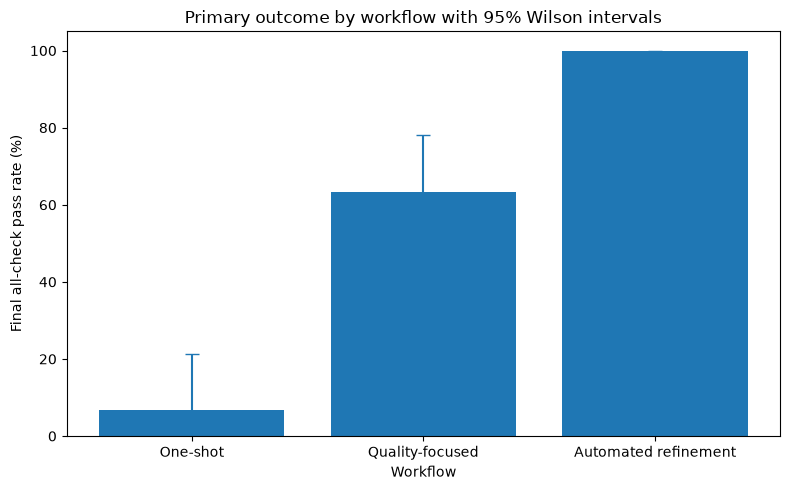

In [18]:
# Figure 1: primary endpoint pass percentages with Wilson confidence intervals.
primary_rates = binary_descriptive.loc[
    binary_descriptive["outcome"] == "finalAllPassed"
].set_index("workflow").reindex(WORKFLOW_ORDER)

x = np.arange(len(WORKFLOW_ORDER))
rates = primary_rates["passRate"].to_numpy() * 100
lower = (primary_rates["passRate"] - primary_rates["ci95Low"]).to_numpy() * 100
upper = (primary_rates["ci95High"] - primary_rates["passRate"]).to_numpy() * 100

figure, axis = plt.subplots(figsize=(8, 5))
axis.bar(x, rates)
axis.errorbar(x, rates, yerr=[lower, upper], fmt="none", capsize=5)
axis.set_xticks(x, [WORKFLOW_LABELS[item] for item in WORKFLOW_ORDER])
axis.set_ylabel("Final all-check pass rate (%)")
axis.set_xlabel("Workflow")
axis.set_ylim(0, 105)
axis.set_title("Primary outcome by workflow with 95% Wilson intervals")
figure.tight_layout()
figure.savefig(
    figures_dir / "inferential_primary_pass_rate_by_workflow.png",
    dpi=300, bbox_inches="tight"
)
plt.show()


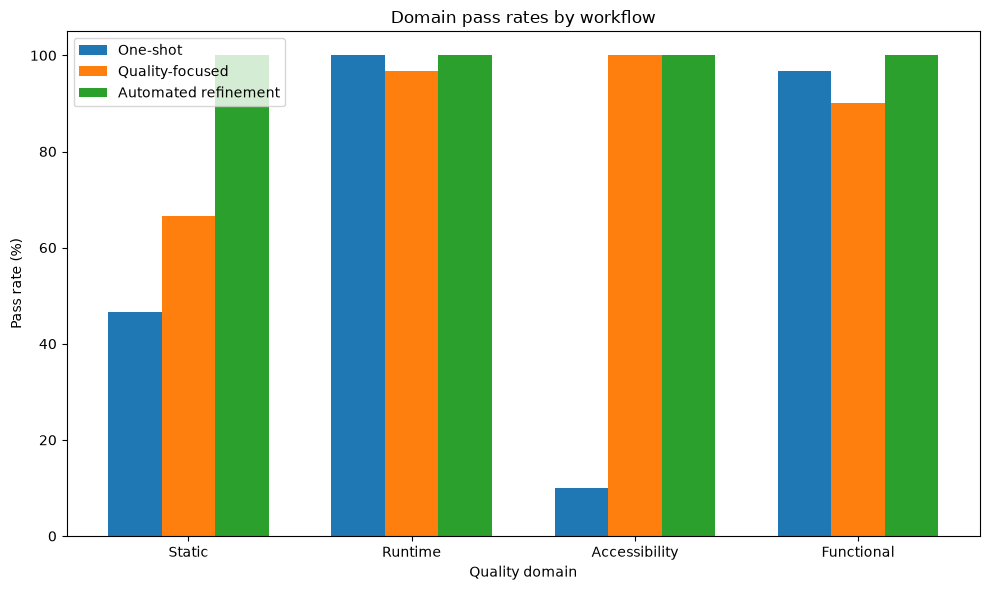

In [19]:
# Figure 2: domain pass percentages by workflow.
domain_rates = binary_descriptive.loc[
    binary_descriptive["outcome"] != "finalAllPassed"
].copy()
domain_order = [
    "finalStaticPassed",
    "finalRuntimePassed",
    "finalAccessibilityPassed",
    "finalFunctionalPassed",
]
domain_labels = {
    "finalStaticPassed": "Static",
    "finalRuntimePassed": "Runtime",
    "finalAccessibilityPassed": "Accessibility",
    "finalFunctionalPassed": "Functional",
}

figure, axis = plt.subplots(figsize=(10, 6))
width = 0.24
domain_x = np.arange(len(domain_order))

for index, workflow in enumerate(WORKFLOW_ORDER):
    values = (
        domain_rates.loc[domain_rates["workflow"] == workflow]
        .set_index("outcome")
        .reindex(domain_order)["passRate"]
        .to_numpy() * 100
    )
    axis.bar(
        domain_x + (index - 1) * width,
        values,
        width=width,
        label=WORKFLOW_LABELS[workflow],
    )

axis.set_xticks(domain_x, [domain_labels[item] for item in domain_order])
axis.set_ylabel("Pass rate (%)")
axis.set_xlabel("Quality domain")
axis.set_ylim(0, 105)
axis.set_title("Domain pass rates by workflow")
axis.legend()
figure.tight_layout()
figure.savefig(
    figures_dir / "inferential_domain_pass_rates_by_workflow.png",
    dpi=300, bbox_inches="tight"
)
plt.show()


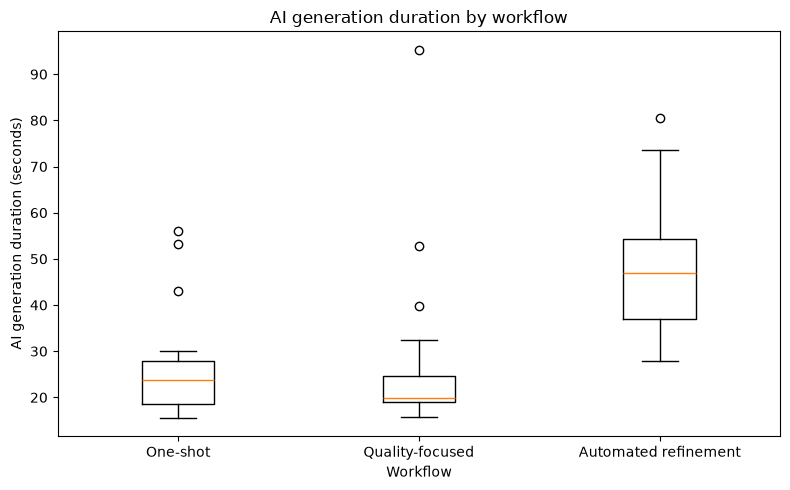

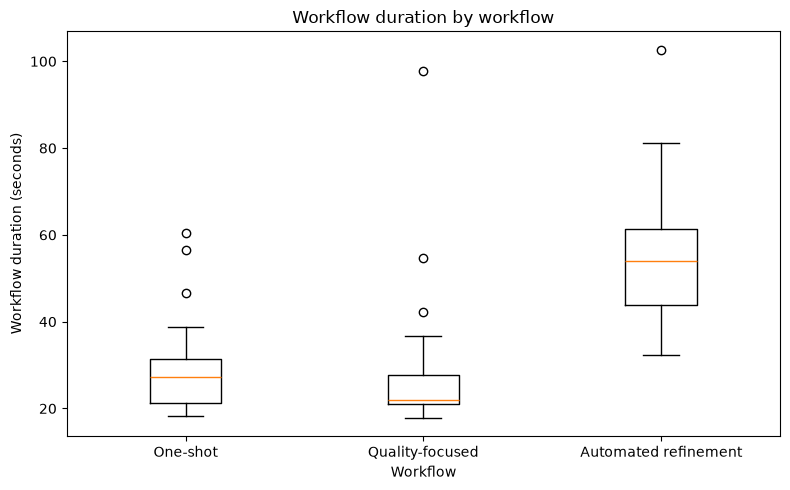

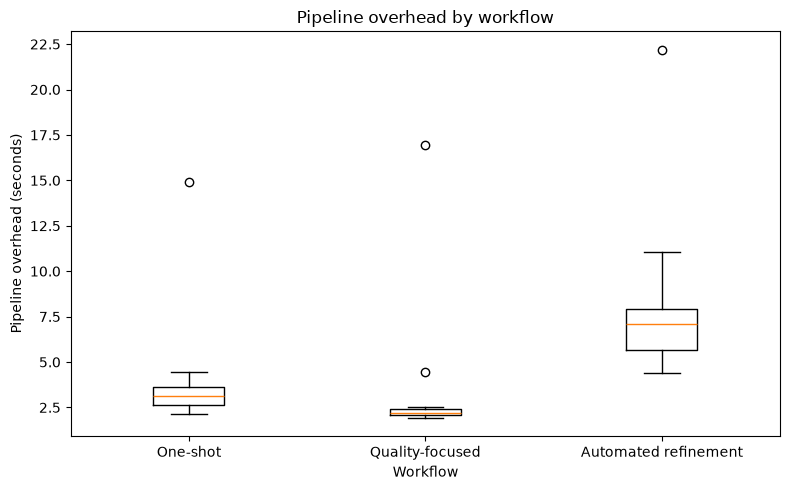

In [20]:
# Figure 3: duration distributions.
duration_outcomes = [
    ("aiGenerationDurationMs", "AI generation duration (seconds)"),
    ("workflowDurationMs", "Workflow duration (seconds)"),
    ("pipelineOverheadMs", "Pipeline overhead (seconds)"),
]

for outcome, ylabel in duration_outcomes:
    data = [
        pd.to_numeric(
            runs.loc[runs["workflow"] == workflow, outcome],
            errors="coerce",
        ).dropna().to_numpy() / 1000
        for workflow in WORKFLOW_ORDER
    ]
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.boxplot(
        data,
        tick_labels=[WORKFLOW_LABELS[item] for item in WORKFLOW_ORDER],
        showfliers=True,
    )
    axis.set_ylabel(ylabel)
    axis.set_xlabel("Workflow")
    axis.set_title(ylabel.replace(" (seconds)", "") + " by workflow")
    figure.tight_layout()
    filename = outcome.replace("Ms", "")
    figure.savefig(
        figures_dir / f"inferential_{filename}_by_workflow.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()


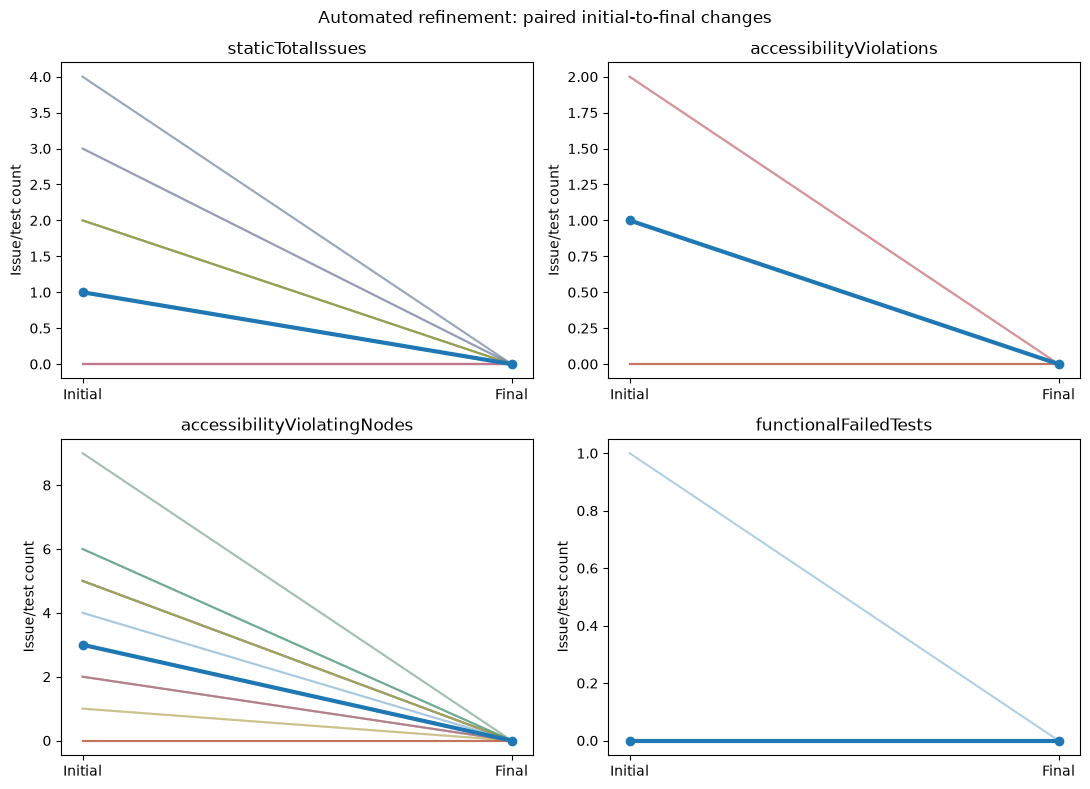

In [21]:
# Figure 4: automated-refinement initial-to-final count changes.
figure, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for axis, (label, (initial_column, final_column)) in zip(
    axes, paired_count_map.items()
):
    initial = pd.to_numeric(automated[initial_column], errors="coerce")
    final = pd.to_numeric(automated[final_column], errors="coerce")
    paired = pd.DataFrame({"Initial": initial, "Final": final}).dropna()
    for _, row in paired.iterrows():
        axis.plot([0, 1], [row["Initial"], row["Final"]], alpha=0.35)
    axis.plot(
        [0, 1],
        [paired["Initial"].median(), paired["Final"].median()],
        marker="o", linewidth=3,
    )
    axis.set_xticks([0, 1], ["Initial", "Final"])
    axis.set_title(label)
    axis.set_ylabel("Issue/test count")

figure.suptitle("Automated refinement: paired initial-to-final changes")
figure.tight_layout()
figure.savefig(
    figures_dir / "inferential_automated_paired_count_changes.png",
    dpi=300, bbox_inches="tight"
)
plt.show()


## 8. Executed interpretation summary

In [22]:
# Build interpretations from executed results rather than hard-coding conclusions.
interpretation_rows = []

# Primary binary endpoint.
primary_tests = binary_pairwise_overall.loc[
    binary_pairwise_overall["outcome"] == "finalAllPassed"
]
for _, row in primary_tests.iterrows():
    rd_pp = row["riskDifferenceAminusB"] * 100
    interpretation_rows.append({
        "section": "Primary outcome",
        "outcome": "finalAllPassed",
        "comparison": f"{WORKFLOW_LABELS[row['groupA']]} vs {WORKFLOW_LABELS[row['groupB']]}",
        "statisticalSignificance": significance_label(row["holmP"]),
        "effectSize": (
            f"Risk difference {rd_pp:+.1f} percentage points; "
            f"corrected OR {row['oddsRatioCorrected']:.2f}"
        ),
        "practicalInterpretation": (
            "The absolute pass-rate difference should be considered alongside "
            "its confidence interval and the small cell sample size."
        ),
    })

# Continuous/count omnibus outcomes.
for _, row in kruskal_overall.iterrows():
    interpretation_rows.append({
        "section": "Continuous/count outcome",
        "outcome": row["outcome"],
        "comparison": "Three-workflow omnibus comparison",
        "statisticalSignificance": significance_label(row["holmP"]),
        "effectSize": (
            f"Kruskal-Wallis epsilon-squared={row['epsilonSquared']:.3f}"
            if np.isfinite(row["epsilonSquared"]) else "Not estimable"
        ),
        "practicalInterpretation": (
            "Inspect workflow medians, interquartile ranges and pairwise "
            "rank-biserial correlations before judging practical importance."
        ),
    })

# Automated binary changes.
for _, row in mcnemar_results.iterrows():
    interpretation_rows.append({
        "section": "Automated refinement",
        "outcome": row["outcome"],
        "comparison": "Initial vs final",
        "statisticalSignificance": significance_label(row["holmP"]),
        "effectSize": (
            f"{int(row['initialFailFinalPass'])} improved and "
            f"{int(row['initialPassFinalFail'])} worsened; "
            f"net change={row['netImprovementProportion'] * 100:+.1f} percentage points"
        ),
        "practicalInterpretation": (
            "The paired direction and number of changed runs are more "
            "informative than the p-value alone when discordant pairs are few."
        ),
    })

# Automated count changes.
for _, row in wilcoxon_results.iterrows():
    interpretation_rows.append({
        "section": "Automated refinement",
        "outcome": row["outcome"],
        "comparison": "Initial vs final",
        "statisticalSignificance": significance_label(row["holmP"]),
        "effectSize": (
            f"Median final-minus-initial change={row['medianChangeFinalMinusInitial']:+.2f}; "
            f"matched rank-biserial={row['matchedRankBiserial']:+.3f} "
            f"({row['effectMagnitude']})"
        ),
        "practicalInterpretation": (
            "Negative count changes represent fewer final issues. "
            "Unchanged runs and all-zero differences remain part of the result."
        ),
    })

interpretation_summary = pd.DataFrame(interpretation_rows)
interpretation_summary.to_csv(
    tables_dir / "dissertation_interpretation_summary.csv", index=False
)
display(interpretation_summary)


,section,outcome,comparison,statisticalSignificance,effectSize,practicalInterpretation
0,Primary outcome,finalAllPassed,Quality-focused vs Automated refinement,statistically significant,Risk difference -36.7 percentage points; corre...,The absolute pass-rate difference should be co...
1,Primary outcome,finalAllPassed,Quality-focused vs One-shot,statistically significant,Risk difference +56.7 percentage points; corre...,The absolute pass-rate difference should be co...
2,Primary outcome,finalAllPassed,Automated refinement vs One-shot,statistically significant,Risk difference +93.3 percentage points; corre...,The absolute pass-rate difference should be co...
3,Continuous/count outcome,aiGenerationDurationMs,Three-workflow omnibus comparison,statistically significant,Kruskal-Wallis epsilon-squared=0.488,"Inspect workflow medians, interquartile ranges..."
4,Continuous/count outcome,workflowDurationMs,Three-workflow omnibus comparison,statistically significant,Kruskal-Wallis epsilon-squared=0.515,"Inspect workflow medians, interquartile ranges..."
5,Continuous/count outcome,pipelineOverheadMs,Three-workflow omnibus comparison,statistically significant,Kruskal-Wallis epsilon-squared=0.721,"Inspect workflow medians, interquartile ranges..."
6,Continuous/count outcome,totalPromptTokens,Three-workflow omnibus comparison,statistically significant,Kruskal-Wallis epsilon-squared=0.815,"Inspect workflow medians, interquartile ranges..."
7,Continuous/count outcome,totalOutputTokens,Three-workflow omnibus comparison,statistically significant,Kruskal-Wallis epsilon-squared=0.620,"Inspect workflow medians, interquartile ranges..."
8,Continuous/count outcome,totalTokens,Three-workflow omnibus comparison,statistically significant,Kruskal-Wallis epsilon-squared=0.623,"Inspect workflow medians, interquartile ranges..."
9,Continuous/count outcome,finalStaticTotalIssues,Three-workflow omnibus comparison,statistically significant,Kruskal-Wallis epsilon-squared=0.211,"Inspect workflow medians, interquartile ranges..."


In [23]:
# Print a concise narrative generated directly from executed tables.
print("INTERPRETATION BOUNDARIES")
print("- Statistical significance is assessed using Holm-adjusted p-values at alpha=0.05.")
print("- Effect sizes and absolute differences are reported separately from significance.")
print("- Practical importance depends on the magnitude, direction, confidence intervals, and resource trade-offs.")
print("- Non-significance is not interpreted as proof of equivalence.")
print("- Specification-stratified results are exploratory when cell sizes are only 10 per workflow.")
print("- Sequence findings are sensitivity checks for temporal drift, not primary workflow effects.")
print("- Intermediate automated-refinement quality states are not inferred because full intermediate quality reports are unavailable.")


INTERPRETATION BOUNDARIES
- Statistical significance is assessed using Holm-adjusted p-values at alpha=0.05.
- Effect sizes and absolute differences are reported separately from significance.
- Practical importance depends on the magnitude, direction, confidence intervals, and resource trade-offs.
- Non-significance is not interpreted as proof of equivalence.
- Specification-stratified results are exploratory when cell sizes are only 10 per workflow.
- Sequence findings are sensitivity checks for temporal drift, not primary workflow effects.
- Intermediate automated-refinement quality states are not inferred because full intermediate quality reports are unavailable.


## 9. Final output validation

In [24]:
expected_table_files = [
    "inferential_binary_pass_rates_overall.csv",
    "inferential_binary_pairwise_fisher_overall.csv",
    "inferential_binary_pass_rates_by_specification.csv",
    "inferential_binary_pairwise_fisher_by_specification.csv",
    "dissertation_binary_workflow_comparisons.csv",
    "inferential_continuous_count_descriptive.csv",
    "inferential_kruskal_wallis_overall.csv",
    "inferential_mann_whitney_overall.csv",
    "inferential_kruskal_wallis_by_specification.csv",
    "inferential_mann_whitney_by_specification.csv",
    "dissertation_kruskal_wallis_summary.csv",
    "inferential_automated_exact_mcnemar.csv",
    "inferential_automated_wilcoxon.csv",
    "inferential_automated_paired_change_by_specification.csv",
    "inferential_sequence_sensitivity.csv",
    "dissertation_interpretation_summary.csv",
]

expected_figure_files = [
    "inferential_primary_pass_rate_by_workflow.png",
    "inferential_domain_pass_rates_by_workflow.png",
    "inferential_aiGenerationDuration_by_workflow.png",
    "inferential_workflowDuration_by_workflow.png",
    "inferential_pipelineOverhead_by_workflow.png",
    "inferential_automated_paired_count_changes.png",
]

output_validation_rows = []
for filename in expected_table_files:
    path = tables_dir / filename
    output_validation_rows.append({
        "type": "table",
        "filename": filename,
        "exists": path.is_file(),
        "nonEmpty": path.is_file() and path.stat().st_size > 0,
    })
for filename in expected_figure_files:
    path = figures_dir / filename
    output_validation_rows.append({
        "type": "figure",
        "filename": filename,
        "exists": path.is_file(),
        "nonEmpty": path.is_file() and path.stat().st_size > 0,
    })

output_validation = pd.DataFrame(output_validation_rows)
display(output_validation)

if not output_validation[["exists", "nonEmpty"]].all().all():
    missing = output_validation.loc[
        ~(output_validation["exists"] & output_validation["nonEmpty"]),
        "filename",
    ].tolist()
    raise AssertionError(f"Expected outputs missing or empty: {missing}")

assert len(runs) == 90
assert len(automated) == 30
assert set(runs["workflow"].dropna().astype(str)) == set(WORKFLOW_ORDER)
assert set(runs["specificationId"].dropna().astype(str)) == set(SPECIFICATION_ORDER)

print("Final validation: PASSED")
print(f"Validated {len(expected_table_files)} CSV tables and {len(expected_figure_files)} PNG figures.")


,type,filename,exists,nonEmpty
0,table,inferential_binary_pass_rates_overall.csv,True,True
1,table,inferential_binary_pairwise_fisher_overall.csv,True,True
2,table,inferential_binary_pass_rates_by_specification...,True,True
3,table,inferential_binary_pairwise_fisher_by_specific...,True,True
4,table,dissertation_binary_workflow_comparisons.csv,True,True
5,table,inferential_continuous_count_descriptive.csv,True,True
6,table,inferential_kruskal_wallis_overall.csv,True,True
7,table,inferential_mann_whitney_overall.csv,True,True
8,table,inferential_kruskal_wallis_by_specification.csv,True,True
9,table,inferential_mann_whitney_by_specification.csv,True,True


Final validation: PASSED
Validated 16 CSV tables and 6 PNG figures.
